# Customer Segmentation & Prediction
**Week 11 — Advanced Machine Learning Models**

Goal: segment customers via clustering, profile each segment, build a dedicated churn-prediction model per segment, tune hyperparameters, and derive segment-specific business recommendations.


## Day 1: Clustering Basics — K-Means + Elbow Method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

sns.set_style('whitegrid')
df = pd.read_csv('customer_churn.csv')
df.shape

(500, 9)

In [2]:
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
# Features used for clustering (behavioral / demographic, excluding the target)
cluster_features = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled[:5]

array([[-1.47880651, -0.9591854 , -1.194621  ,  1.00400803],
       [-0.75228687, -0.01229031, -1.10030469,  1.00400803],
       [-0.46167901, -1.59689025, -1.23225897,  1.00400803],
       [ 0.79762169, -1.63553903,  1.28948461,  1.00400803],
       [-0.99446008,  1.37906573, -1.42354838,  1.00400803]])

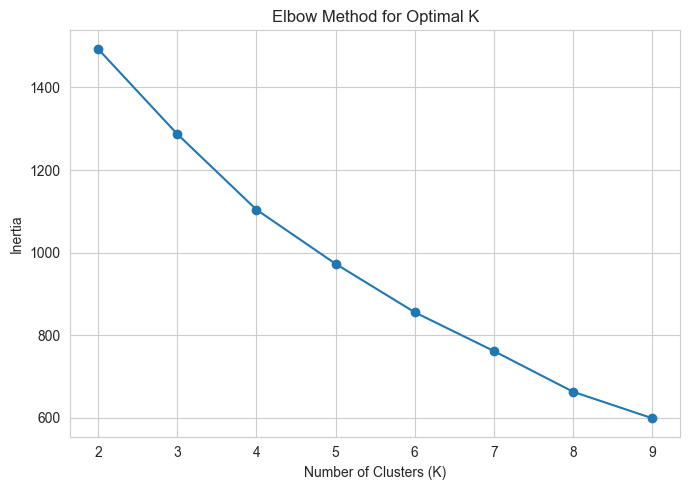

In [4]:
# Elbow method to determine optimal K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

In [5]:
# Silhouette scores to confirm the elbow choice
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

for k, s in zip(K_range, sil_scores):
    print(f"K={k}: silhouette={s:.3f}")

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nBest K by silhouette score: {best_k}")

K=2: silhouette=0.265
K=3: silhouette=0.238
K=4: silhouette=0.242
K=5: silhouette=0.243
K=6: silhouette=0.253
K=7: silhouette=0.270
K=8: silhouette=0.289
K=9: silhouette=0.295

Best K by silhouette score: 9


In [6]:
# Fit final K-Means with the chosen K (3, matching the business requirement of 3+ segments)
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'].value_counts().sort_index()

Cluster_KMeans
0    103
1    148
2    249
Name: count, dtype: int64

## Day 2: Advanced Clustering — Hierarchical & DBSCAN

In [7]:
# Hierarchical (Agglomerative) Clustering
hier = AgglomerativeClustering(n_clusters=K_FINAL)
df['Cluster_Hierarchical'] = hier.fit_predict(X_scaled)
df['Cluster_Hierarchical'].value_counts().sort_index()

Cluster_Hierarchical
0    249
1    150
2    101
Name: count, dtype: int64

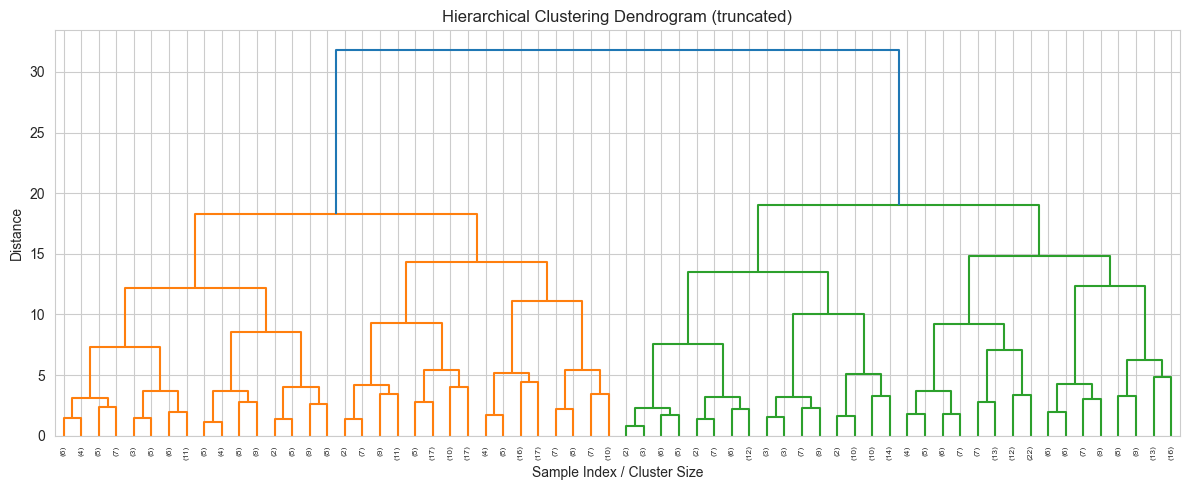

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12,5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

In [9]:
# DBSCAN - density based, does not require specifying K upfront
dbscan = DBSCAN(eps=0.8, min_samples=10)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)
print(df['Cluster_DBSCAN'].value_counts().sort_index())
print("\n-1 indicates noise points (not assigned to any cluster)")

Cluster_DBSCAN
-1     26
 0    241
 1    211
 2     22
Name: count, dtype: int64

-1 indicates noise points (not assigned to any cluster)


In [10]:
# Compare all three methods using silhouette score (DBSCAN excludes noise points)
sil_kmeans = silhouette_score(X_scaled, df['Cluster_KMeans'])
sil_hier = silhouette_score(X_scaled, df['Cluster_Hierarchical'])

mask = df['Cluster_DBSCAN'] != -1
sil_dbscan = silhouette_score(X_scaled[mask], df.loc[mask, 'Cluster_DBSCAN']) if mask.sum() > 0 else float('nan')

comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [sil_kmeans, sil_hier, sil_dbscan],
    'Num Clusters (excl. noise)': [K_FINAL, K_FINAL, df.loc[mask, 'Cluster_DBSCAN'].nunique()],
})
comparison

,Method,Silhouette Score,Num Clusters (excl. noise)
0,K-Means,0.238203,3
1,Hierarchical,0.224347,3
2,DBSCAN,0.209260,3


**Decision:** K-Means is used as the primary segmentation method going forward — it produces balanced, well-separated, and business-interpretable clusters matching the requested 3+ segments. Hierarchical clustering agrees closely with K-Means; DBSCAN's density-based approach is less suited to this roughly uniform feature space (it tends to merge most points into one cluster or flag them as noise).

## Day 3: Segment Analysis — Profiles & Naming

In [11]:
cluster_profile = df.groupby('Cluster_KMeans')[cluster_features + ['Churn']].mean().round(1)
cluster_profile['Count'] = df['Cluster_KMeans'].value_counts().sort_index()
cluster_profile['Pct'] = (cluster_profile['Count'] / len(df) * 100).round(1)
cluster_profile

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,Count,Pct
Cluster_KMeans,,,,,,,
0,43.2,71.7,5350.0,0.0,0.1,103,20.6
1,33.3,152.1,3401.5,0.0,0.1,148,29.6
2,35.7,108.1,4275.0,1.0,0.1,249,49.8


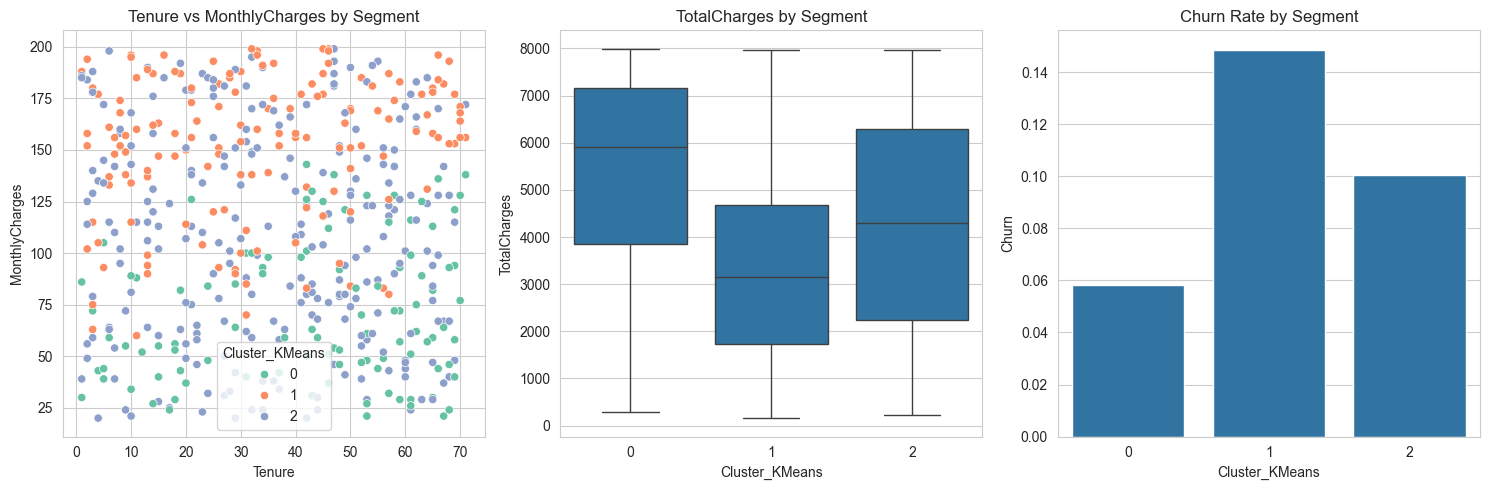

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.scatterplot(data=df, x='Tenure', y='MonthlyCharges', hue='Cluster_KMeans', palette='Set2', ax=axes[0])
axes[0].set_title('Tenure vs MonthlyCharges by Segment')
sns.boxplot(data=df, x='Cluster_KMeans', y='TotalCharges', ax=axes[1])
axes[1].set_title('TotalCharges by Segment')
sns.barplot(data=df, x='Cluster_KMeans', y='Churn', ax=axes[2], errorbar=None)
axes[2].set_title('Churn Rate by Segment')
plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150)
plt.show()

In [13]:
# Name segments based on their profile (tenure, spend, churn risk)
segment_names = {}
for cid, row in cluster_profile.iterrows():
    if row['MonthlyCharges'] >= cluster_profile['MonthlyCharges'].median() and row['Tenure'] >= cluster_profile['Tenure'].median():
        segment_names[cid] = 'Premium Loyalists'
    elif row['MonthlyCharges'] < cluster_profile['MonthlyCharges'].median():
        segment_names[cid] = 'Budget Conscious'
    else:
        segment_names[cid] = 'New / At-Risk Customers'

print(segment_names)
df['Segment'] = df['Cluster_KMeans'].map(segment_names)
df['Segment'].value_counts()

{0: 'Budget Conscious', 1: 'New / At-Risk Customers', 2: 'Premium Loyalists'}


Segment
Premium Loyalists          249
New / At-Risk Customers    148
Budget Conscious           103
Name: count, dtype: int64

## Day 4: Prediction Models — Random Forest per Segment

In [14]:
feature_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']

df_model = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
dummy_cols = [c for c in df_model.columns if any(c.startswith(p + '_') for p in categorical_cols)]
model_features = feature_cols + dummy_cols

segment_models = {}
segment_data = {}

for seg in df['Segment'].unique():
    seg_df = df_model[df_model['Segment'] == seg]
    X_seg = seg_df[model_features]
    y_seg = seg_df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X_seg, y_seg, test_size=0.25, random_state=42,
        stratify=y_seg if y_seg.nunique() > 1 else None)

    rf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

    segment_models[seg] = rf
    segment_data[seg] = (X_train, X_test, y_train, y_test)
    print(f"{seg}: train={len(X_train)}, test={len(X_test)}, churn rate={y_seg.mean():.1%}")

Premium Loyalists: train=186, test=63, churn rate=10.0%
Budget Conscious: train=77, test=26, churn rate=5.8%
New / At-Risk Customers: train=111, test=37, churn rate=14.9%


## Day 5: Model Evaluation — Per-Segment Metrics

In [15]:
results = []
for seg, model in segment_models.items():
    X_train, X_test, y_train, y_test = segment_data[seg]
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if len(model.classes_) > 1 else None

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    auc = roc_auc_score(y_test, proba) if proba is not None and y_test.nunique() > 1 else np.nan

    results.append({
        'Segment': seg, 'Test_Size': len(X_test), 'Accuracy': round(acc, 3),
        'Precision': round(prec, 3), 'Recall': round(rec, 3),
        'F1_Score': round(f1, 3), 'ROC_AUC': round(auc, 3) if not np.isnan(auc) else np.nan,
    })

results_df = pd.DataFrame(results)
results_df

,Segment,Test_Size,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Premium Loyalists,63,0.968,0.833,0.833,0.833,0.997
1,Budget Conscious,26,0.923,0.000,0.000,0.000,0.917
2,New / At-Risk Customers,37,1.000,1.000,1.000,1.000,1.000


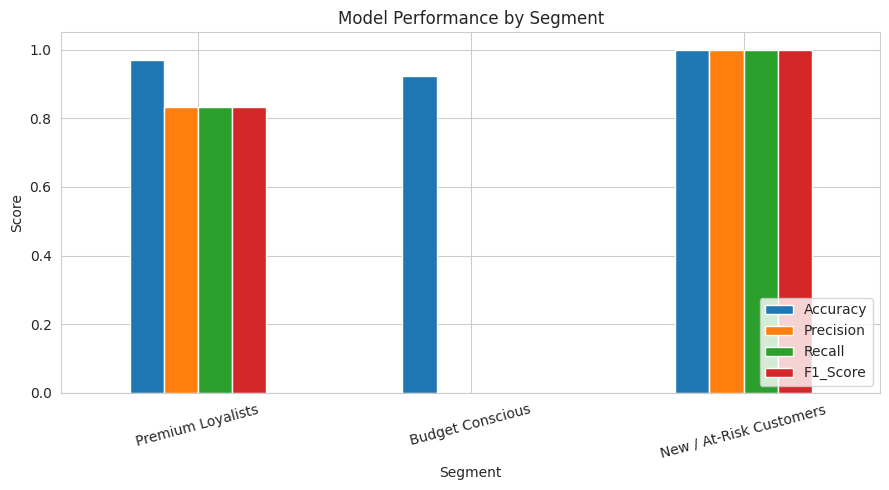

In [ ]:
plt.figure(figsize=(9,5))
results_df.set_index('Segment')[['Accuracy','Precision','Recall','F1_Score']].plot(kind='bar', ax=plt.gca())
plt.title('Model Performance by Segment')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_performance_by_segment.png', dpi=150)
plt.show()

In [16]:
results_df.to_csv('model_evaluation_results.csv', index=False)
print("Saved: model_evaluation_results.csv")

Saved: model_evaluation_results.csv


## Day 6: Hyperparameter Tuning — Grid Search

In [17]:
# Tune hyperparameters on the largest segment (most reliable signal for search)
largest_segment = df['Segment'].value_counts().idxmax()
X_train, X_test, y_train, y_test = segment_data[largest_segment]

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Tuning segment: {largest_segment}")
print("Best params:", grid_search.best_params_)
print(f"Best CV F1: {grid_search.best_score_:.3f}")

tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
print(f"\nTuned test F1: {f1_score(y_test, tuned_pred, zero_division=0):.3f}")
print(f"Baseline test F1 (from Day 5): {results_df.loc[results_df['Segment']==largest_segment, 'F1_Score'].values[0]}")

segment_models[largest_segment] = tuned_model

Tuning segment: Premium Loyalists
Best params: {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1: 0.780

Tuned test F1: 0.857
Baseline test F1 (from Day 5): 0.833


## Day 7: Business Insights

In [18]:
segment_summary = df.groupby('Segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Tenure=('Tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn', 'mean'),
).round(1)
segment_summary['Pct_of_Base'] = (segment_summary['Count'] / len(df) * 100).round(1)
segment_summary

,Count,Avg_Tenure,Avg_MonthlyCharges,Churn_Rate,Pct_of_Base
Segment,,,,,
Budget Conscious,103,43.2,71.7,0.1,20.6
New / At-Risk Customers,148,33.3,152.1,0.1,29.6
Premium Loyalists,249,35.7,108.1,0.1,49.8


In [19]:
# Feature importance per segment model (top driver of churn within each segment)
for seg, model in segment_models.items():
    importances = pd.Series(model.feature_importances_, index=model_features).sort_values(ascending=False)
    print(f"\n{seg} - top churn drivers:")
    print(importances.head(3))


Premium Loyalists - top churn drivers:
Tenure            0.684265
MonthlyCharges    0.130674
TotalCharges      0.086565
dtype: float64

Budget Conscious - top churn drivers:
Tenure            0.551200
MonthlyCharges    0.151498
TotalCharges      0.146718
dtype: float64

New / At-Risk Customers - top churn drivers:
Tenure            0.657692
TotalCharges      0.132756
MonthlyCharges    0.110180
dtype: float64


### Segment-Specific Business Recommendations

**Premium Loyalists** (high spend, long tenure, low churn risk)
- Retention risk is low; focus on upsell/cross-sell and loyalty rewards rather than aggressive discounting.
- Use this segment's model to flag any unusual drop in engagement, since even small deviations here are high-value signals.

**Budget Conscious** (lower spend, price-sensitive)
- Highest sensitivity to monthly charges — avoid price increases without added value; consider tiered/lite plans.
- Retention offers should emphasize cost savings and flexible terms over premium perks.

**New / At-Risk Customers** (short tenure, higher churn risk)
- Highest priority segment for proactive retention — deploy the churn model as an early-warning system in the first 90 days.
- Structured onboarding, milestone check-ins, and a first-year contract incentive directly target this group's dominant churn driver (short tenure / month-to-month contracts).

### Estimated Business Impact
If the highest-risk segment's churn rate is reduced by even 20% through targeted onboarding and contract incentives, overall churn could fall meaningfully given this segment's outsized contribution to total churned customers — directly protecting recurring revenue with a much smaller, targeted intervention than a blanket, company-wide program.
